In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit

from data_reading import read_and_combine_csv
from feature_engineering import FeatureEngineer
from config import Config
import logging
import os

def get_strategy_logger(strategy_name, log_dir='logs'):
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)
        
    logger = logging.getLogger(strategy_name)
    logger.setLevel(logging.INFO)

    if not logger.handlers:
        # 日志文件路径
        log_path = os.path.join(log_dir, f'trading_log_{strategy_name}.log')

        # 文件 handler
        file_handler = logging.FileHandler(log_path, mode='a')
        file_handler.setLevel(logging.INFO)
        file_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))

        # 控制台 handler
        console_handler = logging.StreamHandler()
        console_handler.setLevel(logging.INFO)
        console_handler.setFormatter(logging.Formatter('%(name)s - %(levelname)s - %(message)s'))

        logger.addHandler(file_handler)
        logger.addHandler(console_handler)

    return logger

In [2]:
def calculate_15mins_sharpe_ratio_and_annualized_return(returns):
    """
    计算传入的15分钟频率的收益率数据的年化收益率和Sharpe Ratio
    参数:
    returns (pandas.Series): 已计算的收益率序列
    
    返回:
    dict: 包含年化收益率和Sharpe Ratio
    """
    # 计算收益率的标准差
    returns_std = returns.std()

    # 计算平均收益率
    mean_return = returns.mean()

    total_return = (1 + returns).prod() - 1
    print('total return:',total_return)
    # 年化收益率计算，15分钟频率下每年有 35040 个15分钟周期
    annualized_return = (1 + total_return) ** (35040 / len(returns)) - 1
    # Sharpe Ratio 计算，假设无风险收益率为 0
    sharpe_ratio = mean_return / returns_std * np.sqrt(35040)
    
    cumulative_returns = (1 + returns).cumprod()  # 计算累计收益
    rolling_max = cumulative_returns.cummax()  # 计算滚动最大值
    drawdown = (cumulative_returns - rolling_max) / rolling_max  # 计算回撤
    max_drawdown = drawdown.min() 
    
    return {
        'annualized_return': annualized_return,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown
    }

In [3]:
config = Config()
fe = FeatureEngineer()
fold_name = f'{config.symbols[7]}-spot-klines-15m-from_2018_to_2025'
df = read_and_combine_csv(f'./raw_data/{fold_name}')

正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2022-08.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2025-01.csv
读取文件失败: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2025-01.csv, 错误: year 56971 is out of range
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2018-09.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2018-08.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2022-09.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2020-08.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2020-09.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2019-02.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2021-06.csv
正在读取文件: ./raw_data/ETHUSDT-spot-klines-15m-from_2018_to_2025/ETHUSDT-15m-2021-12.csv
正在读取文件: ./raw_data/ETHUSDT-spot-k

In [4]:
df

,Open time,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
0,2018-01-01 08:00:00,733.01,734.52,722.91,727.31,420.84730,2018-01-01 08:14:59.999,3.062671e+05,867,210.68080,1.532772e+05,0
1,2018-01-01 08:15:00,727.22,728.44,720.03,725.51,586.88558,2018-01-01 08:29:59.999,4.250692e+05,890,351.73472,2.546975e+05,0
2,2018-01-01 08:30:00,725.51,728.61,722.85,723.38,522.11912,2018-01-01 08:44:59.999,3.794493e+05,654,298.03786,2.166539e+05,0
3,2018-01-01 08:45:00,723.33,727.62,722.50,727.62,576.04900,2018-01-01 08:59:59.999,4.177735e+05,703,414.77933,3.008165e+05,0
4,2018-01-01 09:00:00,727.01,728.25,723.00,724.64,320.34994,2018-01-01 09:14:59.999,2.324155e+05,474,122.04581,8.860470e+04,0
...,...,...,...,...,...,...,...,...,...,...,...,...
244937,2025-01-01 06:45:00,3344.07,3346.45,3329.00,3339.88,2793.12000,2025-01-01 06:59:59.999,9.324333e+06,15324,1411.93770,4.715837e+06,0
244938,2025-01-01 07:00:00,3339.88,3343.91,3328.47,3341.91,2654.69870,2025-01-01 07:14:59.999,8.859294e+06,22124,1374.34410,4.586771e+06,0
244939,2025-01-01 07:15:00,3341.91,3345.98,3335.52,3343.45,1130.91660,2025-01-01 07:29:59.999,3.778152e+06,13363,784.78810,2.621702e+06,0
244940,2025-01-01 07:30:00,3343.45,3344.25,3332.39,3339.06,1284.31850,2025-01-01 07:44:59.999,4.285603e+06,12596,630.57880,2.104125e+06,0


In [5]:
df.rename({'Close': 'close',
           'Open': 'open',
           'High': 'high',
           'Low': 'low',
           'Volume': 'volume'}, axis=1, inplace=True)

In [6]:
df = fe.process_data(df)

df['return_15m'] = df['close'].pct_change(1).shift(-1)
config.target_col = 'return_15m'

In [7]:
df['close'].pct_change(1)

0              NaN
1        -0.002475
2        -0.002936
3         0.005861
4        -0.004096
            ...   
244937   -0.001253
244938    0.000608
244939    0.000461
244940   -0.001313
244941   -0.000383
Name: close, Length: 244942, dtype: float64

In [8]:
# 对收益率进行分箱
# 计算滚动波动率（过去 960 根 K 线，10 天）
# window_size = 960*3  # 可以调整这个窗口大小
# window_size = 960*2  # 可以调整这个窗口大小

window_size = 960  # 可以调整这个窗口大小
# window_size = 10000  # 可以调整这个窗口大小
# window_size = 480  # 可以调整这个窗口大小 #很烂
df['rolling_vol'] = df['return_15m'].rolling(window=window_size).std()

# 避免最开始的 NaN
df.dropna(subset=['rolling_vol'], inplace=True)

# 设定features
config.set_feature_cols(df)

# 使用滚动波动率进行分箱（使用一倍和二倍标准差作为分箱边界因为收益率通常被认为近似服从正态分布（尽管实际上有胖尾效应））
def categorize_return(row):
    if row['return_15m'] > 2 * row['rolling_vol']:
        return 4  # 大涨
    elif row['return_15m'] > row['rolling_vol']:
        return 3  # 涨
    elif row['return_15m'] > -row['rolling_vol']:
        return 2  # 震荡
    elif row['return_15m'] > -2 * row['rolling_vol']:
        return 1  # 跌
    else:
        return 0  # 大跌

df['return_class'] = df.apply(categorize_return, axis=1)

In [9]:
# split training and test
train, test = train_test_split(df, test_size=0.1, random_state=42, shuffle=False)

In [10]:
scaler = StandardScaler()
scaler_train = train.copy()
scaler_test = test.copy()
scaler_train[config.feature_cols] = scaler.fit_transform(train[config.feature_cols])
scaler_test[config.feature_cols] = scaler.transform(test[config.feature_cols])

In [11]:
# 时间序列 K 折交叉验证
K = 5
tscv = TimeSeriesSplit(n_splits=K)

# 初始化 OOF 预测
scaler_train['predicted_return'] = np.nan
train['predicted_return'] = np.nan

In [12]:
# 训练 XGBoost 并生成 OOF 预测
for train_index, val_index in tscv.split(train):
    train_fold, val_fold = train.iloc[train_index], train.iloc[val_index]
    
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=6)
    xgb_model.fit(train_fold[config.feature_cols], train_fold[config.target_col])
    
    # 在验证集上预测，并填充到 train['predicted_return']
    scaler_train.loc[val_index, 'predicted_return'] = xgb_model.predict(val_fold[config.feature_cols])
    train.loc[val_index, 'predicted_return'] = scaler_train.loc[val_index, 'predicted_return']

In [13]:
train.shape

(219583, 95)

In [14]:
# 确保没有 NaN
train.dropna(subset=['predicted_return'], inplace=True)
scaler_train.dropna(subset=['predicted_return'], inplace=True)
train.shape

(182985, 95)

In [15]:
# 用完整 XGBoost 训练最终模型，并预测测试集
xgb_model_final = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.05, max_depth=6)
xgb_model_final.fit(train[config.feature_cols], train[config.target_col])
scaler_test['predicted_return'] = xgb_model_final.predict(test[config.feature_cols])
test['predicted_return'] = scaler_test['predicted_return']

In [16]:
# 逻辑回归使用 predicted_return 作为额外特征
log_reg_features = config.feature_cols + ['predicted_return']
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, class_weight='balanced')
log_reg.fit(scaler_train[log_reg_features], scaler_train['return_class'])

/opt/anaconda3/envs/Crypto/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1000,
                   multi_class='multinomial')

In [17]:
# 预测分类
scaler_test['predicted_class'] = log_reg.predict(scaler_test[log_reg_features])

In [18]:
scaler_test['predicted_class']

220542    2
220543    2
220544    2
220545    2
220546    2
         ..
244936    3
244937    3
244938    3
244939    2
244940    2
Name: predicted_class, Length: 24399, dtype: int64

Logistic Regression Accuracy: 0.4316
Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.38      0.11       622
           1       0.07      0.13      0.10      1862
           2       0.91      0.49      0.64     19455
           3       0.08      0.08      0.08      1891
           4       0.06      0.50      0.11       569

    accuracy                           0.43     24399
   macro avg       0.24      0.32      0.21     24399
weighted avg       0.74      0.43      0.53     24399



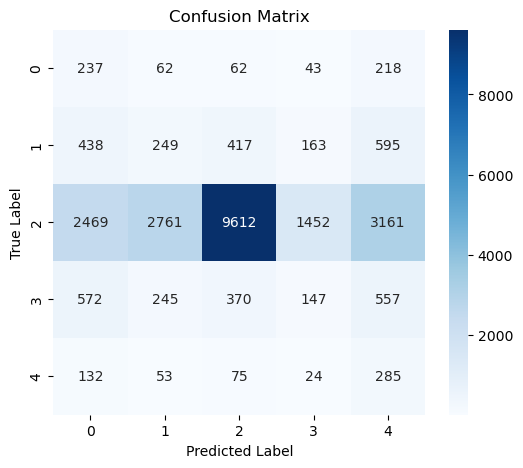

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


# 计算分类准确率
accuracy = accuracy_score(scaler_test['return_class'], scaler_test['predicted_class'])
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

# 打印分类报告（包含 Precision, Recall, F1-score）
print("Classification Report:")
print(classification_report(scaler_test['return_class'], scaler_test['predicted_class']))

# 绘制混淆矩阵
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(scaler_test['return_class'], scaler_test['predicted_class']), annot=True, cmap='Blues', fmt='d', 
            xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

strategy_1 - INFO - Step: 220542, Position: 1, PnL without Fee: 1.0008910358610112, PnL with Fee: 0.9998910358610112, Close Price: 3142.41
strategy_1 - INFO - Step: 220543, Position: 1, PnL without Fee: 0.9994876543799187, PnL with Fee: 0.9984890565120498, Close Price: 3145.21
strategy_1 - INFO - Step: 220544, Position: 1, PnL without Fee: 1.002160761962952, PnL with Fee: 1.0011594933672143, Close Price: 3140.8
strategy_1 - INFO - Step: 220545, Position: 1, PnL without Fee: 1.0068896165681753, PnL with Fee: 1.0058836233276605, Close Price: 3149.2
strategy_1 - INFO - Step: 220546, Position: 1, PnL without Fee: 1.0045920169551394, PnL with Fee: 1.0035883192688166, Close Price: 3164.06
strategy_1 - INFO - Step: 220547, Position: 1, PnL without Fee: 1.0017216085743108, PnL with Fee: 1.0007207787410088, Close Price: 3156.84
strategy_1 - INFO - Step: 220548, Position: 1, PnL without Fee: 1.0008242081714351, PnL with Fee: 0.999824274939632, Close Price: 3147.82
strategy_1 - INFO - Step: 22054

0.0639364163319267
-0.08330266225003058


strategy_1 - INFO - Step: 220839, Position: 1, PnL without Fee: 1.0140901164962617, PnL with Fee: 0.8701097123335032, Close Price: 3144.39
strategy_1 - INFO - Step: 220840, Position: -1, PnL without Fee: 1.0172530964904258, PnL with Fee: 0.8710833933483233, Close Price: 3142.0
strategy_1 - INFO - Step: 220841, Position: -1, PnL without Fee: 1.0186820964344132, PnL with Fee: 0.8723070594394835, Close Price: 3132.2
strategy_1 - INFO - Step: 220842, Position: -1, PnL without Fee: 1.019434432147299, PnL with Fee: 0.8729512915858182, Close Price: 3127.8
strategy_1 - INFO - Step: 220843, Position: 1, PnL without Fee: 1.0236811378819384, PnL with Fee: 0.8748418830616413, Close Price: 3125.49
strategy_1 - INFO - Step: 220844, Position: 1, PnL without Fee: 1.0244280623160646, PnL with Fee: 0.8754802075889525, Close Price: 3138.51
strategy_1 - INFO - Step: 220845, Position: -1, PnL without Fee: 1.0220829152936335, PnL with Fee: 0.871725075404619, Close Price: 3140.8
strategy_1 - INFO - Step: 220

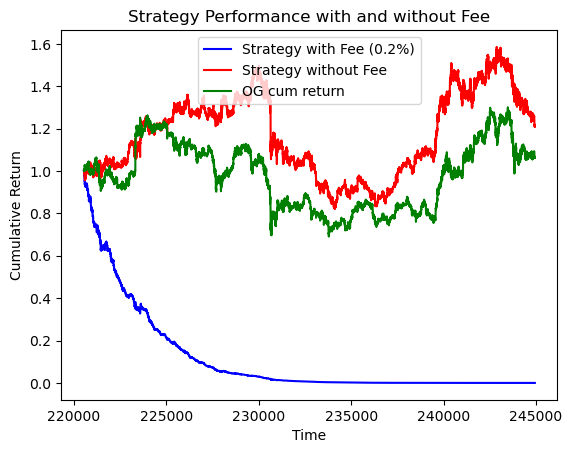

In [20]:
import logging

logger1 = get_strategy_logger('strategy_1')

# strategy 1 
transaction_fee_single_side=0.001
# test['position'] = test['predicted_return'].apply(lambda x: 1 if x > 0 else -1)


test['position'] = test['predicted_return'].apply(lambda x: 1 if x > 0 else -1)
# test['position'] = test['predicted_return'].apply(lambda x: 1 if x > 2*transaction_fee_single_side else(-1 if x<-2*transaction_fee_single_side else 0))
test['position_change'] = test['position'].diff().fillna(test['position'].iloc[0])
# Apply the fee adjustment only when position changes
test['strategy_return_with_fee'] = test['position'] * test['return_15m']

# Apply the fee when there is a position change (from 1 to -1 or -1 to 1)
test['strategy_return_with_fee'] = test['strategy_return_with_fee']  - transaction_fee_single_side * abs(test['position_change'])


print(max(test['strategy_return_with_fee']))
print(min(test['strategy_return_with_fee']))



test['strategy_return'] = test['position'] * test['return_15m']

test['strategy_cum_return_with_fee'] = (1 + test['strategy_return_with_fee']).cumprod()
test['strategy_cum_return_without_fee'] = (1 + test['strategy_return']).cumprod()
test['og_cum_return'] = (1 + test['return_15m']).cumprod()

for index, row in test.iterrows():
    logger1.info(f"Step: {index}, Position: {row['position']}, PnL without Fee: {row['strategy_cum_return_without_fee']}, PnL with Fee: {row['strategy_cum_return_with_fee']}, Close Price: {row['close']}")


plt.plot(test['strategy_cum_return_with_fee'], label="Strategy with Fee (0.2%)", color='b')
plt.plot(test['strategy_cum_return_without_fee'], label="Strategy without Fee", color='r')
plt.plot(test['og_cum_return'], label="OG cum return", color='g')
plt.legend()

plt.title('Strategy Performance with and without Fee')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.show()

In [21]:
test['position_change']

220542    1.0
220543    0.0
220544    0.0
220545    0.0
220546    0.0
         ... 
244936    0.0
244937   -2.0
244938    2.0
244939    0.0
244940    0.0
Name: position_change, Length: 24399, dtype: float64

In [22]:
result = calculate_15mins_sharpe_ratio_and_annualized_return(test['strategy_return'])

print(f"年化收益率: {result['annualized_return']:.4f}")
print(f"Sharpe Ratio: {result['sharpe_ratio']:.4f}")
print(f"Max drawdown: {result['max_drawdown']:.4f}")

total return: 0.20862912264260025
年化收益率: 0.3128
Sharpe Ratio: 0.7473
Max drawdown: -0.4512


In [23]:
(test['predicted_return'] - test['return_15m']).abs().sum()

53.701407666654674

In [24]:
(test['return_15m']).abs().sum()

53.482611130444916

In [25]:
test['return_15m'].abs().mean()

0.002192000128302181

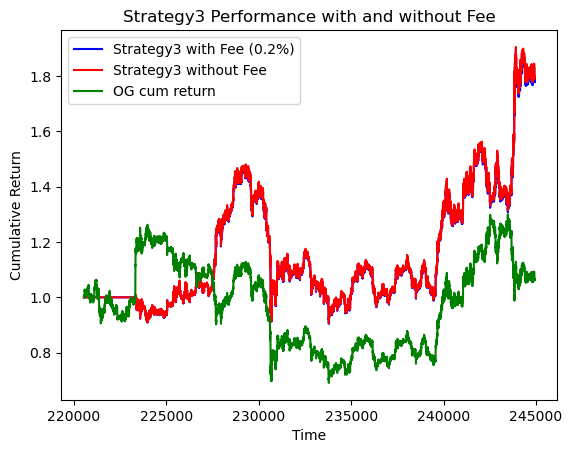

total return: 0.792454375216131
年化收益率: 1.3120
Sharpe Ratio: 1.6996
Max drawdown: -0.3879


In [26]:
# startegy 3，预测收益率明显大于交易费用是才交易

test['signal_3'] = test['predicted_return'].apply(lambda x: 1 if x > 4*transaction_fee_single_side else(-1 if x<-4*transaction_fee_single_side else 0))
test['position_3'] = test['signal_3'].replace(0,np.nan).ffill().fillna(0)
test['strategy3_return'] = test['position_3'] * test['return_15m']

test['position_3_change'] = test['position_3'].diff().fillna(test['position_3'].iloc[0])
test['strategy3_return_with_fee'] = test['position_3'] * test['return_15m']

# Apply the fee when there is a position change (from 1 to -1 or -1 to 1)
test['strategy3_return_with_fee'] = test['strategy3_return_with_fee']  - transaction_fee_single_side * abs(test['position_3_change'])

test['strategy3_return'] = test['position_3'] * test['return_15m']

test['strategy3_cum_return_with_fee'] = (1 + test['strategy3_return_with_fee']).cumprod()
test['strategy3_cum_return_without_fee'] = (1 + test['strategy3_return']).cumprod()
test['og_cum_return'] = (1 + test['return_15m']).cumprod()

plt.plot(test['strategy3_cum_return_with_fee'], label="Strategy3 with Fee (0.2%)", color='b')
plt.plot(test['strategy3_cum_return_without_fee'], label="Strategy3 without Fee", color='r')
plt.plot(test['og_cum_return'], label="OG cum return", color='g')
plt.legend()

plt.title('Strategy3 Performance with and without Fee')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.show()

strategy3_result = calculate_15mins_sharpe_ratio_and_annualized_return(test['strategy3_return'])

print(f"年化收益率: {strategy3_result['annualized_return']:.4f}")
print(f"Sharpe Ratio: {strategy3_result['sharpe_ratio']:.4f}")
print(f"Max drawdown: {strategy3_result['max_drawdown']:.4f}")

In [27]:
sum(transaction_fee_single_side * abs(test['position_3_change']))

0.007

In [28]:
# strategy 2
# no transaction fee
# 交易策略实现
def trading_strategy(predicted_class, current_position):
    """
    根据预测类别调整仓位：
    0 - 大跌：空仓或做空
    1 - 下跌：减少持仓
    2 - 震荡：维持现有仓位
    3 - 上涨：增加持仓
    4 - 大涨：全仓或加杠杆
    """
    if predicted_class == 0:
        return -1  # 清仓或做空
    elif predicted_class == 1:
        return max(-1, current_position - 0.5)  # 减少仓位
    elif predicted_class == 2:
        return current_position  # 维持仓位
    elif predicted_class == 3:
        return min(1, current_position + 0.5)  # 增加仓位
    elif predicted_class == 4:
        return 1  # 满仓
    return current_position

# 应用策略
scaler_test['position'] = 0  # 初始仓位
for i in range(1, len(test)):
    scaler_test.loc[scaler_test.index[i], 'position'] = trading_strategy(scaler_test.loc[scaler_test.index[i], 'predicted_class'], scaler_test.loc[scaler_test.index[i-1], 'position'])


/var/folders/lb/bpxk7kxj49x_zyw9f2vy9yj80000gn/T/ipykernel_90509/2217932362.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scaler_test.loc[scaler_test.index[i], 'position'] = trading_strategy(scaler_test.loc[scaler_test.index[i], 'predicted_class'], scaler_test.loc[scaler_test.index[i-1], 'position'])


In [29]:
scaler_test['position']

220542    0.0
220543    0.0
220544    0.0
220545    0.0
220546    0.0
         ... 
244936    1.0
244937    1.0
244938    1.0
244939    1.0
244940    1.0
Name: position, Length: 24399, dtype: float64

/var/folders/lb/bpxk7kxj49x_zyw9f2vy9yj80000gn/T/ipykernel_90509/94590440.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scaler_test['strategy_cum_return_without_fee'] = (1 + scaler_test['strategy_return']).cumprod()
/var/folders/lb/bpxk7kxj49x_zyw9f2vy9yj80000gn/T/ipykernel_90509/94590440.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scaler_test['og_cum_return'] = (1 + scaler_test['return_15m']).cumprod()
strategy_2 - INFO - Step: 220542, Position: 0.0, PnL without Fee: 1.0, PnL with Fee: 0.0, Close Price: 1.543497

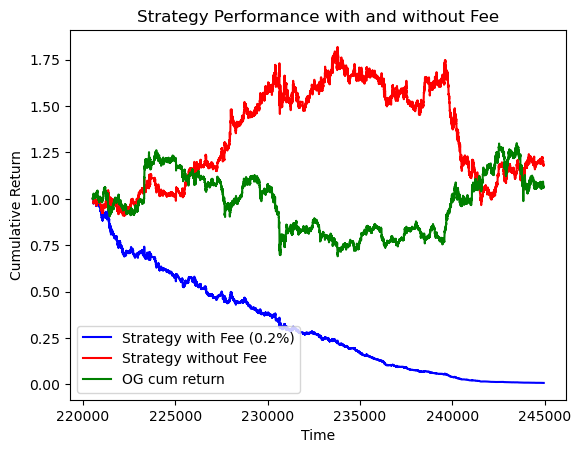

In [30]:
# 配置日志记录器
logger2 = get_strategy_logger('strategy_2')

scaler_test['position_change'] = scaler_test['position'].diff().fillna(scaler_test['position'].iloc[0])
scaler_test['strategy_return_with_fee'] = scaler_test['position'] * scaler_test['return_15m']

# Apply the fee when there is a position change (from 1 to -1 or -1 to 1)
scaler_test['strategy_return_with_fee'] = scaler_test['strategy_return_with_fee']  - transaction_fee_single_side * abs(scaler_test['position_change'])

scaler_test['strategy_return'] = scaler_test['position'] * scaler_test['return_15m']

scaler_test['strategy_cum_return_with_fee'] = (1 + scaler_test['strategy_return_with_fee']).cumprod()
scaler_test['strategy_cum_return_without_fee'] = (1 + scaler_test['strategy_return']).cumprod()
scaler_test['og_cum_return'] = (1 + scaler_test['return_15m']).cumprod()

for index, row in scaler_test.iterrows():
    logger2.info(f"Step: {index}, Position: {row['position']}, PnL without Fee: {row['strategy_cum_return_without_fee']}, PnL with Fee: {row['strategy_return_with_fee']}, Close Price: {row['close']}")

plt.plot(scaler_test['strategy_cum_return_with_fee'], label="Strategy with Fee (0.2%)", color='b')
plt.plot(scaler_test['strategy_cum_return_without_fee'], label="Strategy without Fee", color='r')
plt.plot(scaler_test['og_cum_return'], label="OG cum return", color='g')
plt.legend()

plt.title('Strategy Performance with and without Fee')
plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.show()

In [31]:
result = calculate_15mins_sharpe_ratio_and_annualized_return(scaler_test['strategy_return'])

print(f"年化收益率: {result['annualized_return']:.4f}")
print(f"Sharpe Ratio: {result['sharpe_ratio']:.4f}")
print(f"ax drawdown: {result['max_drawdown']:.4f}")

total return: 0.18107569921199818
年化收益率: 0.2700
Sharpe Ratio: 0.6996
ax drawdown: -0.4687
